## Colab 환경에서 실행 시 환경 설정

In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

#### 코랩에서 한국어 표시하기

In [ ]:
!apt-get install fonts-nanum* -qq
# 다운받은 후 코랩 런타임 다시 시작

In [ ]:
%matplotlib inline
# 별도의 plt.show()를 호출하지 않아도 그래프가 노트북 내부에 자동으로 출력됨
import matplotlib.pyplot as plt
import matplotlib as mpl 

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 패치
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = mpl.font_manager.FontProperties(fname=path).get_name()
plt.rcParams['font.family'] = font_name

# 🔖 CNN 모델 학습 및 다양한 이미지 분류 모델

<a id="lecture_index"></a>
## 수업 목차 

[1. 합성곱 신경망 복습 및 CIFAR-10 데이터 셋을 활용한 분류 모델 만들기](#one)<br>
- 목요일 내용 복습 
- 이미지 데이터셋 구조 이해
- CIFAR-10 데이터 셋을 활용한 분류 모델 만들기

[2. DataLoader 및 데이터 전처리](#two)<br>
- 이미지 폴더 구조에 따라 DataLoader 만들기 
- Dataset, DataLoader 사용 이유
- Resize, ToTensor, Normalize 개념과 시각적 비교
- Quiz1

[3. CNN 모델 성능 개선하기](#three)<br>
- Augmentation (RandomFlip, RandomCrop, ColorJitter 등)
- Dropout, BatchNorm 적용 실습
- EarlyStopping & Checkpoint 활용하기
 
[4. 다양한 이미지 분류 모델](#four)<br>
- CNN이 어떻게 발전했는가 (LeNet → AlexNet → VGG 간략 흐름)
- AlexNet 구조 분석 및 PyTorch 구현하기
- VGG 구조 분석 및 PyTorch 구현하기 
- Quiz3
- 사전학습 모델 

[5. 실습](#five)<br>

## <a id='one'>1️⃣ 합성곱 신경망 복습 및 CIFAR-10 데이터 셋을 활용한 분류 모델 만들기</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 목요일 내용 복습

> CNN(합성곱 신경망)은 이미지와 같이 공간적 구조를 가진 데이터를 효과적으로 처리하기 위한 딥러닝 모델입니다. <br>
> 주요 구성 요소: 합성곱(Convolution), 풀링(Pooling), 활성화 함수(ReLU), 완전 연결층(FC)

```
핵심 용어 정리
• 채널 (Channel): 컬러 이미지의 경우 3채널 (RGB)
• 커널 / 필터: 이미지의 특징을 추출하는 작은 창
• 합성곱 연산: 커널을 이미지에 슬라이딩하며 특징 추출
• 스트라이드 / 패딩: 커널 이동 간격 및 테두리 처리
• 풀링(Pooling): 다운샘플링으로 계산량 및 과적합 줄이기
```

## CIFAR-10 데이터 셋을 활용한 분류 모델 만들기

In [7]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)

In [8]:
img, label = next(iter(trainloader))

In [9]:
img.shape, label.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

In [10]:
img[0].permute(1, 2, 0).shape

torch.Size([32, 32, 3])

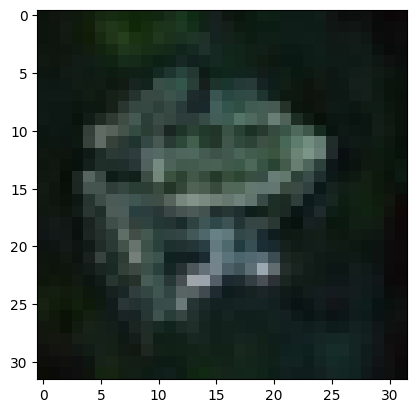

In [11]:
import matplotlib.pyplot as plt

plt.imshow(img[3].permute(1, 2, 0))

In [12]:
import torch.optim as optim
import torch.nn as nn 

class CNN(nn.Module):
    def __init__(self): 
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
        self.fc1 = nn.Linear(32 * 8 * 8, 120)
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))

        return x
    
cnn = CNN()
params = cnn.parameters()
optimizer = optim.Adam(params, lr=0.001)
criterion = nn.CrossEntropyLoss()

## <a id='two'>2️⃣ 데이터 전처리 및 DataLoader</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 이미지 폴더 구조에 따라 DataLoader 만들기

> PyTorch는 torchvision.datasets.ImageFolder를 통해 폴더 구조 기반 이미지 분류 데이터셋을 쉽게 불러올 수 있다

### train / val 데이터 셋으로 나누어진 경우

```bash
dataset1/
  train/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
  val/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
```

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 전처리 정의
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()         # 이미지 데이터를 학습 가능한 형태로 바꿔주는 함수 (0~1 사이의 값으로 정규화) 
])

In [95]:
# 2. ImageFolder로 데이터셋 생성
train_dataset = datasets.ImageFolder(root='dataset1/train', transform=transform)
val_dataset = datasets.ImageFolder(root='dataset1/val', transform=transform)

In [96]:
train_dataset.classes

['cat', 'dog']

In [97]:
train_dataset.class_to_idx

{'cat': 0, 'dog': 1}

In [98]:
len(train_dataset.targets)

8000

In [99]:
len(train_dataset.imgs)

8000

In [100]:
train_loader = DataLoader(train_dataset, shuffle=True, num_workers=8) # batch_size, shuffle, num_workers 
val_loader = DataLoader(val_dataset, shuffle=False, num_workers=8)

In [101]:
imgs, labels = next(iter(train_loader))

In [102]:
# 첫번째 이미지 뽑기 
img = imgs[0]  # [C, H, W]
label = labels[0].item()

# 이미지를 numpy 배열로 변환
img_np = img.permute(1, 2, 0).numpy()  # [H, W, C]
img_np = (img_np * 255).astype(np.uint8)

# 4. RGB → BGR (OpenCV는 BGR로 처리)
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

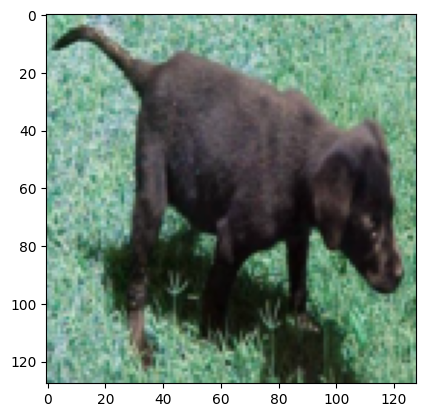

In [103]:
plt.imshow(img_bgr)

In [104]:
train_dataset.class_to_idx

{'cat': 0, 'dog': 1}

### train/val 폴더로 나누어져 있지 않은 경우

```bash
dataset2/
    cats/
      cat001.jpg
      ...
    dogs/
      dog001.jpg
      ...
```

In [105]:
from torch.utils.data import DataLoader, random_split

full_dataset = datasets.ImageFolder(root='dataset2', transform=transform)

total_size = len(full_dataset)
train_size = int(total_size * 0.8)
val_size = int(total_size * 0.1)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

In [106]:
full_dataset.class_to_idx
len(train_dataset), len(val_dataset), len(test_dataset)

(8000, 1000, 1000)

In [107]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset,batch_size=16, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset,batch_size=16, shuffle=False, num_workers=8)

In [108]:
(128 + 2*1 - 3)/1 + 1

128.0

In [109]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 128 x 128 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (128 -> 64)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (64 -> 32)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # (32 -> 16)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),  # (16x16x128 = 32768)
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # 출력 클래스 2
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [110]:
cnn = CNN()
params = cnn.parameters()
optimizer = optim.Adam(params, lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [111]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
train_model(cnn, train_loader, loss_fn, optimizer, epochs=5)

In [113]:
# 첫번째 이미지 뽑기 
img = imgs[0]  # [C, H, W]
label = labels[0].item()

# 이미지를 numpy 배열로 변환
img_np = img.permute(1, 2, 0).numpy()  # [H, W, C]
img_np = (img_np * 255).astype(np.uint8)

# 4. RGB → BGR (OpenCV는 BGR로 처리)
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

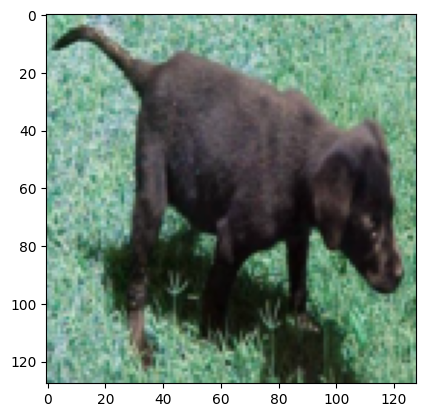

In [114]:
plt.imshow(img_bgr)

In [115]:
full_dataset.class_to_idx

{'cat': 0, 'dog': 1}

In [116]:
imgs.shape, labels.shape

(torch.Size([1, 3, 128, 128]), torch.Size([1]))

In [117]:
64 * 32 * 32

65536

In [118]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (128 -> 64)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (64 -> 32)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # (32 -> 16)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),  # (16x16x128 = 32768)
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 출력 클래스 10개
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [120]:
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
# 여기서는 에러나는게 정상입니다. 데이터 셋 중에 파일을 정상적으로 불러올 수 없는 파일이 포함되어 있어서 오류가 남
# 오류를 읽어보세요! 
train_model(model, train_loader, criterion, optimizer, epochs=10)

UnidentifiedImageError: Caught UnidentifiedImageError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/Users/jihyeokjeong/.anyenv/envs/pyenv/versions/human_lecture/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/jihyeokjeong/.anyenv/envs/pyenv/versions/human_lecture/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jihyeokjeong/.anyenv/envs/pyenv/versions/human_lecture/lib/python3.11/site-packages/torch/utils/data/dataset.py", line 420, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jihyeokjeong/.anyenv/envs/pyenv/versi

### Dataset 사용 이유

- 데이터를 불러오는 방식을 통합할 수 있다 (__ getitem __ 메서드 안에 원하는 대로 데이터 셋을 불러올 수 있음)
- 다양한 형식의 데이터를 로드할 수 있다 (이미지, csv, txt)
- 변환 적용: 전처리 및 데이터 증강을 원하는 방식 대로 적용 가능 
- 메모리 절약: 전체 데이터를 한 번에 메모리에 올리지 않고 필요할 때만 불러올 수 있음 

### DataLoader 사용 이유

- 딥러닝 모델은 대량의 데이터를 한 번에 처리하기 어려움 → Mini-Batch 학습 
- DataLoader는 데이터를 자동으로 배치로 묶고, 셔플하고, 병렬로 로딩해주는 역할을 함 
- 데이터를 미리 로드해서 GPU가 데이터를 기다리지 않도록 함 (메모리 최적화) 

In [123]:
from torch.utils.data import DataLoader, Dataset

In [ ]:
from PIL import Image, UnidentifiedImageError # PIL: 이미지 처리 라이브러리 

In [126]:
li = [1, 2, 3]
len(li)

3

In [127]:
image = Image.open('dataset2/cat/0.jpg')

### 오류나는 이미지 데이터를 처리하기 위한 Custom Dataset 만들기

In [ ]:
import os 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image, UnidentifiedImageError

class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir 
        self.transform = transform
        self.classes = [folder for folder in os.listdir(root_dir) if not folder.startswith('.')]
        self.class_dict = {class_: idx for idx, class_ in enumerate(self.classes)}
        self.image_paths, self.labels = self.get_file_paths_labels()
        self.error_paths = [] # 문제가 있는 index 값 저장 
    
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]
        
        if self.check_image_file(image_path, index): 
            image = Image.open(image_path) # PIL 이미지로 저장 
            
            if self.transform: 
                transformed_image = self.transform(image)
                return transformed_image, label
            else: 
                return image, label
        else: 
            return self.__getitem__((index+1) % len(self))
    
    def __len__(self): 
        return len(self.image_paths)
    
    def get_file_paths_labels(self):
        file_paths = []
        labels = []
        for folder in self.classes: 
            for file in os.listdir(os.path.join(self.root_dir, folder)):
                file_path = os.path.join(self.root_dir, folder)
                file_paths.append(os.path.join(file_path, file))
                labels.append(self.class_dict[folder])
                
        return file_paths, labels 
        
    def check_image_file(self, image_path, index):  
        try: 
            image = Image.open(image_path)
            if image.mode == 'RGB': 
                return True
            else: 
                return False 
        except UnidentifiedImageError:
            self.error_paths.append(index)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (128 -> 64)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (64 -> 32)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # (32 -> 16)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),  # (16x16x128 = 32768)
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)  # 출력 클래스 10개
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            # print(images.shape, labels.shape)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
        
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()         # 이미지 데이터를 학습 가능한 형태로 바꿔주는 함수 (0~1 사이의 값으로 정규화) 
])

full_dataset = CustomDataset('dataset2', transform)

train_size = int(len(full_dataset) * 0.8)
val_size = int(len(full_dataset) * 0.1)
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(train_dataset, batch_size=16, shuffle=False) 
test_loader = DataLoader(train_dataset, batch_size=16, shuffle=False) # num_workers=8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_model(model, train_loader, criterion, optimizer, epochs=10)

### 🧩 Quiz 1

1. random_split()을 사용할 때 주의할 점은 무엇인가요?

random_split()은 데이터셋을 무작위로 나누지만, 클래스 비율이 유지되지 않습니다. <br>
따라서 클래스 불균형 문제가 생길 수 있으며, 재현성을 위해 generator에 seed를 고정하는 것도 중요합니다.

2. transforms.ToTensor()를 하면 어떤 일이 일어날까요?

```
a) 정규화한다
b) 이미지 크기를 바꾼다
c) 0 ~ 255 범위의 이미지를 0 ~ 1 범위의 이미지 Tensor로 바꾼다
d) 텐서를 이미지로 바꾼다
```

c

3. DataLoader의 주요 기능이 아닌 것은?
```
a) 데이터를 배치 단위로 제공
b) 데이터를 시각화해줌
c) 데이터를 셔플함
d) 데이터를 병렬로 로드함
```

b

## 전처리 

### Resize - 크기 맞추기 
> 모델 입력 크기는 고정되어야 함. 다양한 크기의 이미지를 하나의 크기로 통일하기 위한 함수

In [ ]:
transforms.Resize((64, 64))

### ToTensor() – 이미지를 Tensor로 변환

> 이미지(0 ~ 255 범위)를 PyTorch 텐서(0 ~ 1 범위)로 변환 <br>

In [ ]:
transforms.ToTensor()

### Normalize() – 정규화

> 데이터의 평균과 표준편차를 기준으로 분포를 정규화 → 학습 안정성 향상

In [ ]:
transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # -1 ~ 1 사이의 값으로 정규화 

# 만약 정확한 값을 구하고 싶다면, 전체 데이터셋에 대해 mean과 std를 계산해서 적용할 수 있음

Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

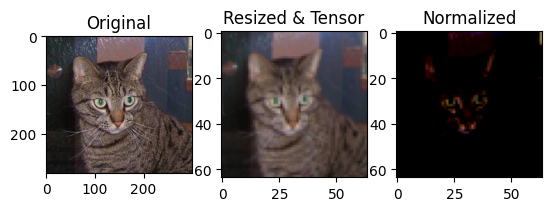

In [43]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("dataset2/cat/1.jpg")

# 원본 이미지
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")

# Resize + ToTensor
t1 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
plt.subplot(1, 3, 2)
plt.imshow(t1(img).permute(1, 2, 0))
plt.title("Resized & Tensor")

# Normalize
t2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
img_norm = t2(img)
plt.subplot(1, 3, 3)
plt.imshow(img_norm.permute(1, 2, 0).clip(0, 1))
plt.title("Normalized")
plt.show()

## <a id='three'>3️⃣ CNN 모델 성능 개선하기</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 데이터 증강 (Data Augmentation)

> 오버피팅(overfitting)을 방지하고, 모델의 일반화 성능을 향상시키기 위해 학습 데이터를 다양하게 변형하는 기법입니다.

기법 | 설명 
---|---
RandomHorizontalFlip() | 좌우 반전 
RandomCrop(size) | 랜덤한 위치에서 잘라내기 
ColorJitter() | 밝기, 대비, 색조 등을 랜덤하게 변경

In [139]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [146]:
import matplotlib.pyplot as plt

dataset = datasets.ImageFolder("dataset1/train", transform=transform)
data_loader = DataLoader(dataset, batch_size=4, shuffle=False)

augmented_dataset = datasets.ImageFolder("dataset1/train", transform=transform_aug)
aug_loader = DataLoader(augmented_dataset, batch_size=4, shuffle=False)

images, _ = next(iter(data_loader))
aug_images, _ = next(iter(aug_loader))

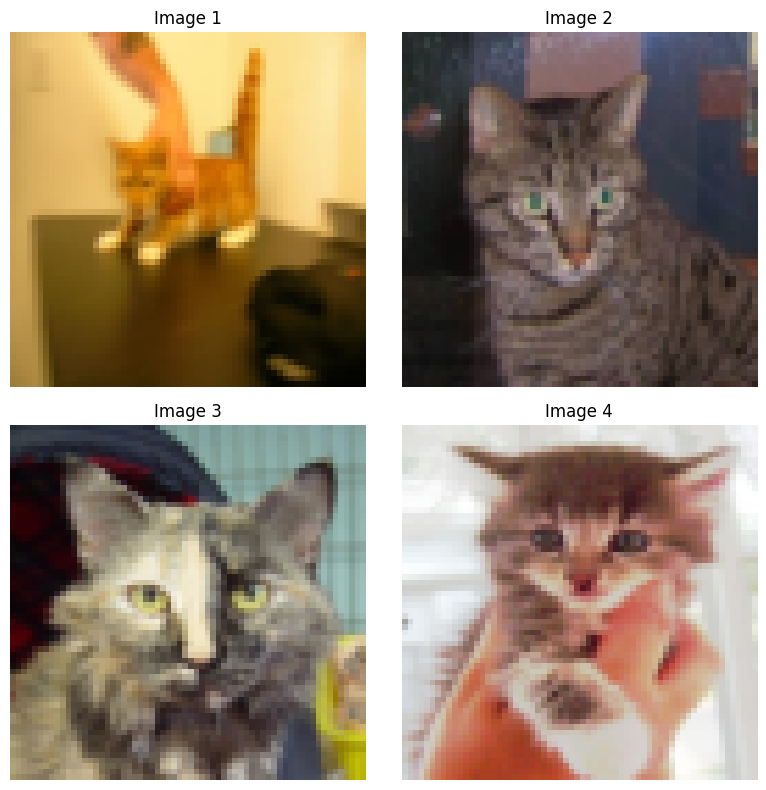

In [147]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# 2. 이미지 4개를 서브플롯에 표시
for i, ax in enumerate(axes.flat):
    # 이미지를 텐서에서 numpy 배열로 변환
    img = images[i].numpy().transpose((1, 2, 0))  # CHW -> HWC로 변환
    
    # 이미지를 표시
    ax.imshow(img)
    ax.axis('off')  # 축 숨기기
    ax.set_title(f"Image {i+1}")  # 각 이미지에 제목 추가

# 레이아웃 자동 조정
plt.tight_layout()
plt.show()

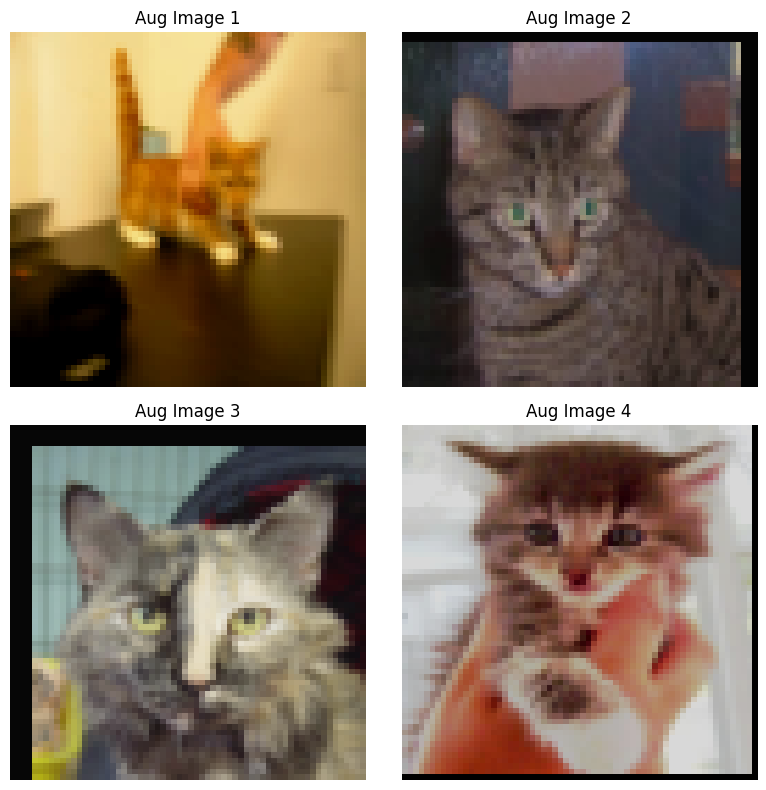

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# 2. 이미지 4개를 서브플롯에 표시
for i, ax in enumerate(axes.flat):
    # 이미지를 텐서에서 numpy 배열로 변환
    img = aug_images[i].numpy().transpose((1, 2, 0))  # CHW -> HWC로 변환
    img = img * [0.5, 0.5, 0.5] + [0.5, 0.5, 0.5]
    
    # 이미지를 표시
    ax.imshow(img)
    ax.axis('off')  # 축 숨기기
    ax.set_title(f"Aug Image {i+1}")  # 각 이미지에 제목 추가

# 레이아웃 자동 조정
plt.tight_layout()
plt.show()

## Dropout & Batch Normalization

> [Dropout] 학습 시 무작위로 일부 뉴런을 제거하여 과적합 방지 <br>
> [Batch Normalization] 각 배치에서 입력 분포를 정규화 → 학습 안정화, 빠른 수렴 

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

## EarlyStopping & Checkpoint 활용하기

> [EarlyStopping] 검증 성능이 더 이상 개선되지 않으면 학습 중단 (Overfitting 방지) <br> 
> [Checkpoint] 모델의 가중치를 저장해두고, 가장 좋은 시점의 모델을 나중에 불러오기 

In [76]:
torch.save(model.state_dict(), "best_model.pth")

In [ ]:
# 모델 저장
torch.save(model.state_dict(), "best_model.pth") # state_dict() -> 가중치와 바이어스 그리고 기타 모델의 상태 반환 (학습 가능한 모든 파라미터를 포함하고 있음)

# 모델 로드
model.load_state_dict(torch.load("best_model.pth"))

In [80]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
valset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader = DataLoader(valset, batch_size=32, shuffle=False)

In [89]:
(128 + 2 - 3) + 1  

128

In [90]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))  # 128
        x = torch.max_pool2d(x, 2)     # 64
        x = torch.relu(self.conv2(x))  
        x = torch.max_pool2d(x, 2)     # 32
        x = x.view(x.size(0), -1)   
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.01, checkpoint_path='best_model.pth'):
        self.patience = patience
        self.best_loss = None
        self.checkpoint_path = checkpoint_path
        self.delta = delta 
        self.counter = 0
        self.stop = False
        
    def __call__(self, valid_loss, model):
        if self.best_loss is None:
            self.best_loss = valid_loss
        elif self.best_loss > valid_loss + self.delta:  
            self.best_loss = valid_loss
            
            # 수업시간에 잘 못 설명한 부분! model.save X -> torch.save O
            torch.save(model.state_dict(), self.checkpoint_path)
        else: 
            self.counter += 1
            if self.patience < self.counter: 
                self.stop = True        

In [93]:
model = CNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

earlystopping = EarlyStopping()

# 훈련 루프
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 검증 손실 계산
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
        
    val_loss /= len(val_loader)
    
    earlystopping(val_loss, model)
    
    if earlystopping.stop == True: 
        break 
    print(f"Epoch {epoch+1}, Train Loss: {running_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Train Loss: 0.6798, Val Loss: 0.5868


AttributeError: 'CNNModel' object has no attribute 'save'